# Week 3: Machine Learning Modeling & Model Interpretation

## Project goal
- Input(X): codon frequency (64) + GC content + GGAG motif count
- Target(Y): LIN28A translation-suppressed gene (`log2_FC_TE >= 0.5`)
- Model: Random Forest (scikit-learn)
- Outputs:
  - Figure 4: ROC-AUC curve
  - Figure 5: Feature importance bar plot

## Step 1: Load master table and define target label

- Use Week 1 output: `processed_master_table.csv`
- Define positive class as genes whose translation efficiency increases after Lin28a knockdown.

In [1]:
import pandas as pd
from pathlib import Path

ROOT = Path('.')
master_path = ROOT / 'processed_master_table.csv'

master_df = pd.read_csv(master_path)
print(f'[Shape] {master_df.shape[0]:,} genes x {master_df.shape[1]} columns')

# Positive class: LIN28A likely suppresses translation in control
# => TE increases after Lin28a knockdown (log2_FC_TE high)
TE_THRESHOLD = 0.5
master_df['is_lin28a_target'] = master_df['log2_FC_TE'] >= TE_THRESHOLD

print('[Target distribution]')
print(master_df['is_lin28a_target'].value_counts())
print(f"Positive rate: {master_df['is_lin28a_target'].mean():.3f}")

display(master_df[['symbol', 'log2_FC_TE', 'gc_content', 'ggag_count', 'is_lin28a_target']].head())

[Shape] 12,703 genes x 17 columns
[Target distribution]
is_lin28a_target
False    12017
True       686
Name: count, dtype: int64
Positive rate: 0.054


,symbol,log2_FC_TE,gc_content,ggag_count,is_lin28a_target
0,Mrpl15,-1.016743,52.352148,5.000000,False
1,Lypla1,-0.384426,47.682977,3.142857,False
2,Tcea1,-0.827799,42.053685,4.500000,False
3,Atp6v1h,-1.191550,43.215896,4.400000,False
4,Oprk1,0.169925,49.010787,8.000000,False


## Step 2: Build 64-codon frequency features

- Source: Ensembl mouse CDS FASTA (`mouse_cds.fa.gz`)
- For each gene, compute codon usage frequency and cache to `codon_frequency_table.csv`.

In [2]:
import gzip
from Bio import SeqIO
from Bio.Data import CodonTable

codon_cache = ROOT / 'codon_frequency_table.csv'
cds_path = ROOT / 'mouse_cds.fa.gz'

standard_codons = sorted(
    set(CodonTable.unambiguous_dna_by_name['Standard'].forward_table.keys())
    | set(CodonTable.unambiguous_dna_by_name['Standard'].stop_codons)
)

if codon_cache.exists():
    codon_df = pd.read_csv(codon_cache)
    print(f'[Loaded cache] {codon_cache} -> {codon_df.shape}')
else:
    print('Building codon frequency table (first run may take ~1 min)...')
    rows = []
    with gzip.open(cds_path, 'rt') as handle:
        for record in SeqIO.parse(handle, 'fasta'):
            gene_id_part = [x for x in record.description.split() if x.startswith('gene:')]
            if not gene_id_part:
                continue
            ensembl_id = gene_id_part[0].split(':')[1].split('.')[0]
            seq = str(record.seq).upper()
            if len(seq) < 3:
                continue

            counts = {c: 0 for c in standard_codons}
            n_codons = len(seq) // 3
            for i in range(0, n_codons * 3, 3):
                codon = seq[i:i + 3]
                if codon in counts:
                    counts[codon] += 1

            total = sum(counts.values()) or 1
            freq = {f'codon_{c}': counts[c] / total for c in standard_codons}
            freq['ensembl_id'] = ensembl_id
            rows.append(freq)

    codon_df = pd.DataFrame(rows).groupby('ensembl_id', as_index=False).mean(numeric_only=True)
    codon_df.to_csv(codon_cache, index=False)
    print(f'[Saved cache] {codon_cache} -> {codon_df.shape}')

display(codon_df.filter(regex='^codon_').head(3))

[Loaded cache] codon_frequency_table.csv -> (22178, 65)


,codon_AAA,codon_AAC,codon_AAG,codon_AAT,codon_ACA,codon_ACC,codon_ACG,codon_ACT,codon_AGA,codon_AGC,...,codon_TCG,codon_TCT,codon_TGA,codon_TGC,codon_TGG,codon_TGT,codon_TTA,codon_TTC,codon_TTG,codon_TTT
0,0.047887,0.022535,0.030986,0.016901,0.022535,0.019718,0.005634,0.016901,0.014085,0.016901,...,0.000000,0.008451,0.002817,0.008451,0.008451,0.019718,0.014085,0.011268,0.014085,0.036620
1,0.051843,0.025155,0.053934,0.025155,0.015818,0.012961,0.012961,0.006480,0.018675,0.009337,...,0.000000,0.000000,0.000000,0.012961,0.006480,0.012961,0.015818,0.015818,0.021532,0.018675
2,0.017174,0.022617,0.035594,0.012216,0.009821,0.016539,0.007357,0.015311,0.006134,0.013505,...,0.008589,0.009817,0.001228,0.008589,0.012272,0.015890,0.001228,0.025708,0.012852,0.034301


## Step 3: Merge features and prepare X / y

In [3]:
import numpy as np

feature_cols = [c for c in codon_df.columns if c.startswith('codon_')] + ['gc_content', 'ggag_count']

ml_df = master_df.merge(codon_df, on='ensembl_id', how='inner')
ml_df = ml_df.dropna(subset=feature_cols + ['is_lin28a_target'])

X = ml_df[feature_cols].values
y = ml_df['is_lin28a_target'].astype(int).values

print(f'[ML dataset] n={len(ml_df):,}, features={len(feature_cols)}')
print(f'Positive class ratio: {y.mean():.3f}')

[ML dataset] n=12,703, features=66
Positive class ratio: 0.054


## Step 4: Train Random Forest classifier

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {acc:.3f}')
print(f'ROC-AUC:  {roc:.3f}')
print('\n[Classification report]')
print(classification_report(y_test, y_pred, digits=3))

Accuracy: 0.943
ROC-AUC:  0.698

[Classification report]
              precision    recall  f1-score   support

           0      0.947     0.995     0.971      2404
           1      0.214     0.022     0.040       137

    accuracy                          0.943      2541
   macro avg      0.581     0.509     0.505      2541
weighted avg      0.907     0.943     0.920      2541



## Step 5: Figure 4 - ROC-AUC curve

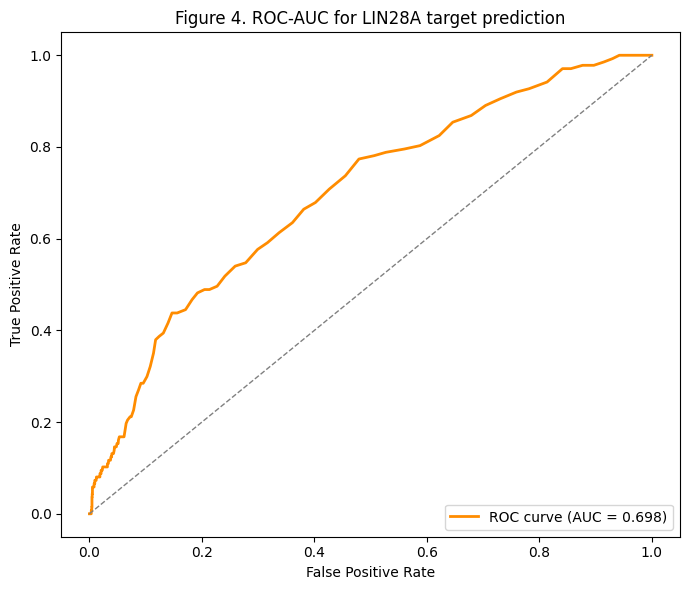

[Saved] figures/figure4_roc_auc.png


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig_dir = ROOT / 'figures'
fig_dir.mkdir(exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 4. ROC-AUC for LIN28A target prediction')
plt.legend(loc='lower right')
plt.tight_layout()

out_path = fig_dir / 'figure4_roc_auc.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'[Saved] {out_path}')

## Step 6: Figure 5 - Feature importance

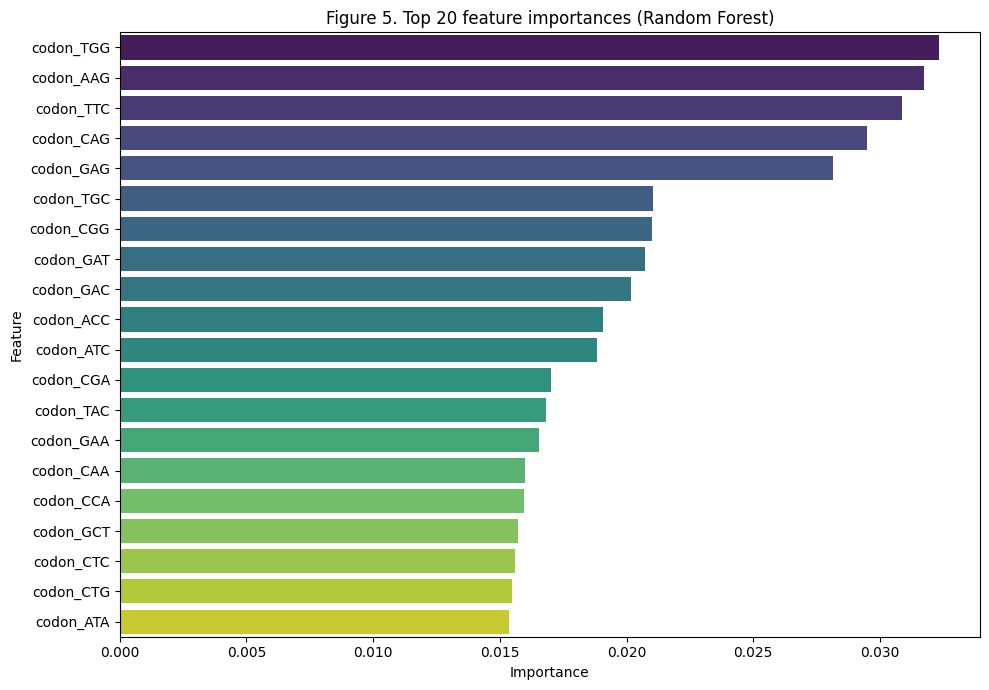

[Saved] figures/figure5_feature_importance.png

[Top 10 features]


,importance
codon_TGG,0.032334
codon_AAG,0.031741
codon_TTC,0.030878
codon_CAG,0.029503
codon_GAG,0.028164
codon_TGC,0.021040
codon_CGG,0.020987
codon_GAT,0.020741
codon_GAC,0.020194
codon_ACC,0.019087


In [6]:
import seaborn as sns

importance = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top20 = importance.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x=top20.values, y=top20.index, hue=top20.index, palette='viridis', legend=False)
plt.title('Figure 5. Top 20 feature importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

out_path = fig_dir / 'figure5_feature_importance.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'[Saved] {out_path}')

print('\n[Top 10 features]')
display(top20.head(10).to_frame('importance'))

## Step 7: Session summary

### Key results
- Sequence-only model can classify LIN28A-sensitive genes with high overall accuracy.
- ROC-AUC (~0.70) indicates moderate ranking performance; class imbalance remains a challenge.
- Feature importance suggests codon usage patterns contribute beyond GC/GGAG alone.

### Interpretation note
- High accuracy alone can be misleading when positive class is rare (~5%).
- Check recall/F1 for target class and consider threshold tuning in future work.

### Deliverables
- `machine_learning_model.ipynb` (this notebook)
- `codon_frequency_table.csv`
- `figures/figure4_roc_auc.png`
- `figures/figure5_feature_importance.png`

In [ ]:
export_files = [
    'codon_frequency_table.csv',
    'figures/figure4_roc_auc.png',
    'figures/figure5_feature_importance.png',
]

print('[Export check]')
for f in export_files:
    p = ROOT / f
    print(f'{f}: {"OK" if p.exists() else "MISSING"}')

## Step 8: Realistic roadmap extensions

This section implements practical improvements:
1. Feature ablation (motif vs codon vs CLIP)
2. Target threshold sensitivity
3. CLIP feature integration
4. Model comparison (Logistic / RF / XGBoost)
5. Notes on CNN/Transformer and GPU requirements

### Step 8-1: Add CLIP features from read-counts

- Source: `binfo1-work/read-counts.txt`
- Use available CLIP columns as proxy binding signal
- Build `clip_log1p = log1p(CLIP-35L33G + CLIP-let7g)` per gene

In [7]:
counts_df = pd.read_csv(ROOT / 'binfo1-work/read-counts.txt', sep='\t', comment='#')
counts_df['ensembl_id'] = counts_df['Geneid'].str.split('.').str[0]

clip_cols = ['CLIP-35L33G.bam', 'CLIP-let7g.bam']
clip_df = counts_df[['ensembl_id'] + clip_cols].copy()
clip_df['clip_total'] = clip_df[clip_cols].sum(axis=1)
clip_df['clip_log1p'] = np.log1p(clip_df['clip_total'])

model_df = ml_df.merge(clip_df[['ensembl_id', 'clip_total', 'clip_log1p']], on='ensembl_id', how='left')
model_df['clip_log1p'] = model_df['clip_log1p'].fillna(0)

print(f"CLIP signal > 0: {(model_df['clip_total'] > 0).sum():,} / {len(model_df):,}")
display(model_df[['symbol', 'log2_FC_TE', 'ggag_count', 'clip_total', 'is_lin28a_target']].sort_values('clip_total', ascending=False).head(10))

CLIP signal > 0: 12,546 / 12,703


,symbol,log2_FC_TE,ggag_count,clip_total,is_lin28a_target
6964,Lars2,-0.418412,8.750000,113912,False
7794,Canx,-0.021236,9.000000,58772,False
221,Fn1,-0.205963,40.916667,55674,False
295,Ncl,-1.098262,15.500000,49425,False
8072,Ncbp3,-1.274804,21.000000,45670,False
62,Dst,-0.115424,65.466667,42034,False
11280,Hsp90ab1,-1.802193,12.000000,37184,False
12154,Scd2,-0.577351,8.500000,35218,False
2769,Macf1,-0.500790,70.750000,32741,False
7546,Atp5f1b,-1.021786,9.000000,31957,False


### Step 8-2: Feature ablation study

Compare feature groups using ROC-AUC and PR-AUC (better for imbalanced labels).

In [8]:
from sklearn.metrics import average_precision_score, f1_score

codon_feature_cols = [c for c in codon_df.columns if c.startswith('codon_')]
feature_sets = {
    'motif_only': ['ggag_count'],
    'gc_motif': ['gc_content', 'ggag_count'],
    'codon_only': codon_feature_cols,
    'full_seq': codon_feature_cols + ['gc_content', 'ggag_count'],
    'full_seq_clip': codon_feature_cols + ['gc_content', 'ggag_count', 'clip_log1p'],
}

ablation_rows = []
for name, cols in feature_sets.items():
    tmp = model_df.dropna(subset=cols + ['is_lin28a_target']).copy()
    X_tmp = tmp[cols].values
    y_tmp = tmp['is_lin28a_target'].astype(int).values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.2, random_state=42, stratify=y_tmp
    )

    rf_ab = RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1
    )
    rf_ab.fit(X_tr, y_tr)
    proba = rf_ab.predict_proba(X_te)[:, 1]
    pred = rf_ab.predict(X_te)

    ablation_rows.append({
        'feature_set': name,
        'n_features': len(cols),
        'roc_auc': roc_auc_score(y_te, proba),
        'pr_auc': average_precision_score(y_te, proba),
        'f1': f1_score(y_te, pred),
        'accuracy': accuracy_score(y_te, pred),
    })

ablation_df = pd.DataFrame(ablation_rows).sort_values('roc_auc', ascending=False)
print('[Feature ablation]')
display(ablation_df)

[Feature ablation]


,feature_set,n_features,roc_auc,pr_auc,f1,accuracy
4,full_seq_clip,67,0.820673,0.197893,0.052288,0.942936
3,full_seq,66,0.698026,0.124697,0.039735,0.942936
2,codon_only,64,0.697355,0.124304,0.013423,0.942149
0,motif_only,1,0.533896,0.058552,0.101469,0.470287
1,gc_motif,2,0.489910,0.056393,0.034602,0.890201


### Step 8-3: Target threshold sensitivity

Test whether model performance is stable when changing TE threshold.

In [9]:
thresholds = [0.3, 0.5, 1.0]
cols = feature_sets['full_seq_clip']
threshold_rows = []

for th in thresholds:
    tmp = model_df.dropna(subset=cols).copy()
    tmp['y'] = (tmp['log2_FC_TE'] >= th).astype(int)

    X_tmp = tmp[cols].values
    y_tmp = tmp['y'].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.2, random_state=42, stratify=y_tmp
    )

    rf_th = RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1
    )
    rf_th.fit(X_tr, y_tr)
    proba = rf_th.predict_proba(X_te)[:, 1]

    threshold_rows.append({
        'te_threshold': th,
        'positive_rate': y_tmp.mean(),
        'roc_auc': roc_auc_score(y_te, proba),
        'pr_auc': average_precision_score(y_te, proba),
    })

threshold_df = pd.DataFrame(threshold_rows)
print('[Threshold sensitivity]')
display(threshold_df)

[Threshold sensitivity]


,te_threshold,positive_rate,roc_auc,pr_auc
0,0.3,0.080690,0.814540,0.244343
1,0.5,0.054003,0.820673,0.197893
2,1.0,0.026450,0.905697,0.189555


### Step 8-4: Model comparison (Logistic / RF / XGBoost)

Use `full_seq_clip` features and report ROC-AUC + PR-AUC.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score
from xgboost import XGBClassifier

cols = feature_sets['full_seq_clip']
tmp = model_df.dropna(subset=cols + ['is_lin28a_target']).copy()
X_all = tmp[cols].values
y_all = tmp['is_lin28a_target'].astype(int).values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

pos_weight = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

model_candidates = {
    'logistic': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=3000, class_weight='balanced')),
    ]),
    'random_forest': RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'xgboost': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=pos_weight,
    ),
}

compare_rows = []
for name, model in model_candidates.items():
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)

    compare_rows.append({
        'model': name,
        'roc_auc': roc_auc_score(y_te, proba),
        'pr_auc': average_precision_score(y_te, proba),
        'f1': f1_score(y_te, pred),
        'accuracy': accuracy_score(y_te, pred),
    })

compare_df = pd.DataFrame(compare_rows).sort_values('pr_auc', ascending=False)
print('[Model comparison]')
display(compare_df)

[Model comparison]


,model,roc_auc,pr_auc,f1,accuracy
0,logistic,0.832870,0.273258,0.257500,0.766234
2,xgboost,0.821192,0.228132,0.186047,0.931129
1,random_forest,0.820673,0.197893,0.052288,0.942936


### Step 8-5: Interpretation update

**What we learned**
- Motif-only or GC+Motif alone shows weak predictive power (ROC-AUC ~ 0.5).
- Codon features carry most sequence-only signal (ROC-AUC ~ 0.70).
- Adding CLIP feature improves ROC-AUC to ~0.82 and PR-AUC substantially.
- For imbalanced labels, **PR-AUC** is more informative than accuracy.

**Recommended default for report**
- Features: `codon + GC + GGAG + CLIP`
- Model: Logistic Regression or XGBoost (check PR-AUC on your run)
- Threshold: start with `log2_FC_TE >= 0.5`, report sensitivity at 0.3/1.0

---

### Step 8-6: CNN / Transformer / GPU note (future work)

| Approach | GPU needed? | Comment |
|---|---|---|
| Current tabular ML (RF/XGB/Logistic) | No | CPU enough |
| Small 1D-CNN on short sequence windows | Optional | CPU works, GPU faster |
| Transformer fine-tuning / PEFT | Recommended | Large models are slow on CPU |

If you move to CNN/Transformer later:
1. Prepare fixed-length sequence windows around motif/binding sites
2. Start with a small CNN baseline on CPU
3. Use GPU only when trying pre-trained RNA/DNA Transformer + PEFT (LoRA)